In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns

In [2]:
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 100)

In [3]:
BASE_DIR = Path.cwd().parent
ARTIFACTS_DIR = BASE_DIR / 'artifacts'
ARTIFACTS_DATA_DIR = ARTIFACTS_DIR / 'data'
ARTIFACTS_SLOB_DATA = ARTIFACTS_DATA_DIR / 'slob.parquet'
ARTIFACTS_SLOB_DATA.exists()

True

In [4]:
ARTIFACTS_PLOTS_DIR = ARTIFACTS_DIR / 'runs' / 'plots' / 'eda'
ARTIFACTS_DATA_FEATURES_DIR = ARTIFACTS_DATA_DIR / 'slob_features.parquet'

ARTIFACTS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
def save_fig(fig:Figure, name: str):
    path = ARTIFACTS_PLOTS_DIR / f'{name}.png'
    fig.savefig(fname=path, bbox_inches='tight', dpi=130)
    print(f"Saved ->{path.relative_to(BASE_DIR)}")

In [6]:
slob = pd.read_parquet(ARTIFACTS_SLOB_DATA)
slob = slob.sort_values(['SKU', 'Week']).reset_index(drop=True)
print(
    f"Loaded {slob.shape[0]:,} rows x {slob.shape[1]} cols | "
    f"{slob['SKU'].nunique()} SKUs | {slob['Week'].min().date()} -> {slob['Week'].max().date()}"
)


Loaded 290,450 rows x 26 cols | 1850 SKUs | 2023-01-02 -> 2025-12-29


In [7]:
slob.head()

,Week,SKU,Product_Category,ABC,Date_First_Listed,Time_to_Expiry_Days,Units_Sold,Stock_Level,Lead_Time,Safety_Stock,Reorder_Level,Price,Promotion,Seasonal_Index,Overall_CPI,Food_CPI,Non_Food_CPI,Inflation_Rate,Rolling_4W_Avg,Rolling_8W_Avg,ADI,CV2,Zero_Demand_Ratio,Consec_Zero_Weeks,Inventory_Turnover,SLOB_Label
0,2023-01-02,Amul_Biscuits_0166,Ambient Grocery Foods,A,2023-02-07,180,287,511,8.2,336,672,136.23,0,0.85,300.54,319.48,297.43,6.4,287.00,287.00,1.0329,0.1103,0.0318,0,0.5616,0
1,2023-01-09,Amul_Biscuits_0166,Ambient Grocery Foods,A,2023-02-07,180,303,633,8.2,346,692,136.23,0,0.85,300.54,319.48,297.43,6.4,295.00,295.00,1.0329,0.1103,0.0318,0,0.4787,0
2,2023-01-16,Amul_Biscuits_0166,Ambient Grocery Foods,A,2023-02-07,180,260,632,8.2,332,664,136.23,1,0.85,300.54,319.48,297.43,6.4,283.33,283.33,1.0329,0.1103,0.0318,0,0.4114,0
3,2023-01-23,Amul_Biscuits_0166,Ambient Grocery Foods,A,2023-02-07,180,306,568,8.2,339,678,136.23,0,0.85,300.54,319.48,297.43,6.4,289.00,289.00,1.0329,0.1103,0.0318,0,0.5387,0
4,2023-01-30,Amul_Biscuits_0166,Ambient Grocery Foods,A,2023-02-07,180,227,461,8.2,321,642,136.23,0,0.85,300.54,319.48,297.43,6.4,274.00,276.60,1.0329,0.1103,0.0318,0,0.4924,0


#### 1. Data Quality

Missing Values

In [8]:
slob.isna().sum()

Week                   0
SKU                    0
Product_Category       0
ABC                    0
Date_First_Listed      0
Time_to_Expiry_Days    0
Units_Sold             0
Stock_Level            0
Lead_Time              0
Safety_Stock           0
Reorder_Level          0
Price                  0
Promotion              0
Seasonal_Index         0
Overall_CPI            0
Food_CPI               0
Non_Food_CPI           0
Inflation_Rate         0
Rolling_4W_Avg         0
Rolling_8W_Avg         0
ADI                    0
CV2                    0
Zero_Demand_Ratio      0
Consec_Zero_Weeks      0
Inventory_Turnover     0
SLOB_Label             0
dtype: int64

Duplicates

In [9]:
slob.duplicated().sum()

np.int64(0)

**Panel Structure**

Confirm if this is a balanced panel: every SKU has the same number of weekly observations

In [10]:
weeks_per_sku = slob.groupby('SKU', observed=True).size()
n_weeks_total = slob.Week.nunique()

print(f"Number of Weeks: {n_weeks_total:,}")
print(f"SKUs: {slob.SKU.nunique():,}")
print(f"Weeks per SKU - min/max: {weeks_per_sku.min():,} / {weeks_per_sku.max():,}")
print(f"All SKUs have {n_weeks_total:,} rows? {(weeks_per_sku == n_weeks_total).all()}")

Number of Weeks: 157
SKUs: 1,850
Weeks per SKU - min/max: 157 / 157
All SKUs have 157 rows? True


In [11]:
gap_days = slob.groupby('SKU', observed=True)['Week'].diff().dt.days
print(f'Non-first-row gaps observed: {sorted(gap_days.dropna().unique())}')

Non-first-row gaps observed: [np.float64(7.0)]


Overall distribution of the target (Slob Label) column

In [12]:
slob_rate = slob.SLOB_Label.mean()
print(f"Overall SLOB rate: {slob_rate:.2%} ({slob.SLOB_Label.sum():,} / {len(slob):,} row-weeks)")

Overall SLOB rate: 52.70% (153,080 / 290,450 row-weeks)


Saved ->artifacts\runs\plots\eda\01_target_balance.png


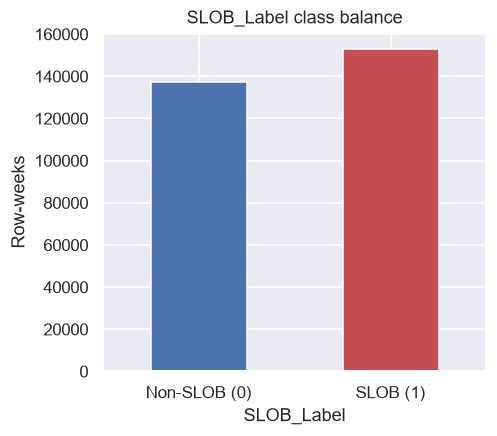

In [13]:
fig, ax = plt.subplots(figsize=(4.5, 4))
slob.SLOB_Label.value_counts().sort_index().plot(
    kind='bar',
    ax=ax, 
    color=["#4C72B0", "#C44E52"]
)

ax.set_xticklabels(['Non-SLOB (0)', 'SLOB (1)'], rotation=0)
ax.set_ylabel('Row-weeks')
ax.set_title('SLOB_Label class balance')
save_fig(fig=fig, name='01_target_balance')
plt.show()

**Observation:** 52.7% of the observations indicate SLOB=1. Slight class imbalance

SLOB_Label VS ABC

In [14]:
ct_pct = pd.crosstab(slob.ABC, slob.SLOB_Label, normalize="index")
print(ct_pct.round(3))

SLOB_Label      0      1
ABC                     
A           1.000  0.000
B           0.911  0.089
C           0.000  1.000


Saved ->artifacts\runs\plots\eda\02_slob_rate_by_abc.png


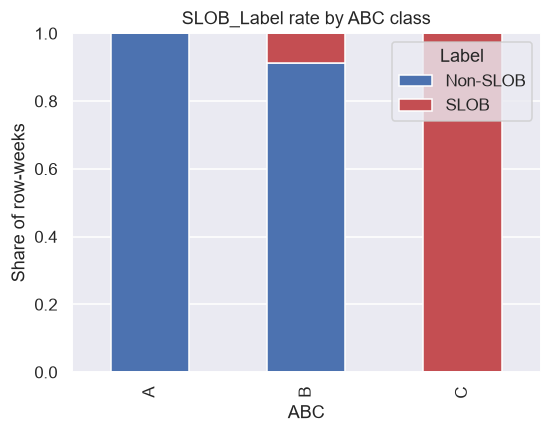

In [15]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ct_pct.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Share of row-weeks")
ax.set_title("SLOB_Label rate by ABC class")
ax.legend(["Non-SLOB", "SLOB"], title="Label")
save_fig(fig, "02_slob_rate_by_abc")
plt.show()

**Observation:** ABC == 'A' implies SLOB_Label == 0 in 100% of rows, ABC == 'C' implies SLOB_Label == 1 in 100% of rows, and only within ABC == 'B' (≈8.9% SLOB rate) does the label carry any real variation.

In [16]:
label_variability = slob.groupby("SKU", observed=True)["SLOB_Label"].nunique()
static_skus = (label_variability == 1).sum()
print(f"SKUs with a CONSTANT SLOB_Label across all 157 weeks: "
      f"{static_skus} / {len(label_variability)}  ({static_skus/len(label_variability):.1%})")
print(f"SKUs where the label actually changes over time: {(label_variability > 1).sum()}")


SKUs with a CONSTANT SLOB_Label across all 157 weeks: 1846 / 1850  (99.8%)
SKUs where the label actually changes over time: 4


**Observation**

The label is **constant for the full 157-week history in 99.8% of SKUs (1,846 / 1,850)** - only 4 SKUs ever flip status. 

As given: this is fundamentally a **static per-SKU classification label**, not a time-varying signal that changes week to week in response to demand dynamics.

X-tics of Demand(Units_Sold)

Saved ->artifacts\runs\plots\eda\03_units_sold_distribution.png


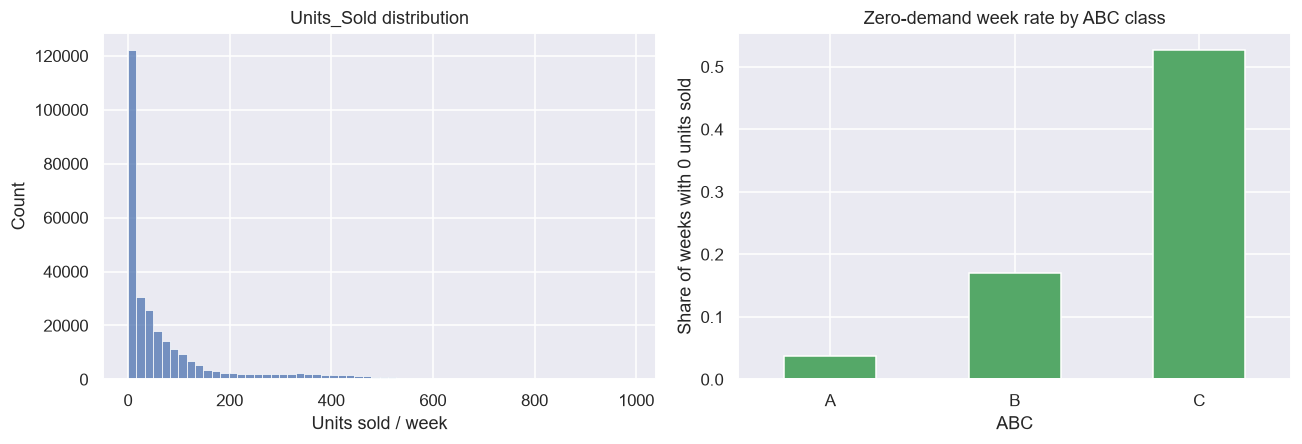

Overall zero-demand week rate: 32.26%
ABC
A    0.038148
B    0.170319
C    0.527452
dtype: float64


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.histplot(slob.Units_Sold, bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Units_Sold distribution")
axes[0].set_xlabel("Units sold / week")

zero_rate_by_abc = slob.groupby("ABC", observed=True).apply(
    lambda g: (g["Units_Sold"] == 0).mean(), include_groups=False
)
zero_rate_by_abc.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Zero-demand week rate by ABC class")
axes[1].set_ylabel("Share of weeks with 0 units sold")
axes[1].set_xticklabels(zero_rate_by_abc.index, rotation=0)

fig.tight_layout()
save_fig(fig, "03_units_sold_distribution")
plt.show()

overall_zero_rate = (slob.Units_Sold == 0).mean()
print(f"Overall zero-demand week rate: {overall_zero_rate:.2%}")
print(zero_rate_by_abc)


#### Intermittency classifiication (Syntetos)

## 5 · Intermittency classification (Syntetos–Boylan)

Computed here on the **full per-SKU history** purely for descriptive SKU
segmentation (it answers *"what kind of demand pattern does this product
have, overall?"*) 

- **ADI** (Average Demand Interval) = total weeks / weeks with non-zero demand
- **CV²** = (std of non-zero demand / mean of non-zero demand)²
- Classification thresholds (Syntetos & Boylan, 2005): ADI = 1.32, CV² = 0.49


In [18]:
def sb_stats(g):
    u = g["Units_Sold"].values
    nz = u[u > 0]
    n, n_nz = len(u), len(nz)
    adi = n / n_nz if n_nz > 0 else np.inf
    cv2 = (nz.std() / nz.mean()) ** 2 if n_nz > 0 and nz.mean() > 0 else np.nan
    return pd.Series({"ADI": adi, "CV2": cv2, "n_nonzero_weeks": n_nz})

sb = slob.groupby("SKU", observed=True).apply(sb_stats, include_groups=False).reset_index()

def classify(row):
    if row["ADI"] < 1.32 and row["CV2"] < 0.49:
        return "Smooth"
    if row["ADI"] >= 1.32 and row["CV2"] < 0.49:
        return "Intermittent"
    if row["ADI"] < 1.32 and row["CV2"] >= 0.49:
        return "Erratic"
    return "Lumpy"

sb["demand_class"] = sb.apply(classify, axis=1)
sb = sb.merge(slob[["SKU", "ABC", "Product_Category"]].drop_duplicates(), on="SKU")

print(sb["demand_class"].value_counts())
print()
print(pd.crosstab(sb["demand_class"], sb["ABC"]))


demand_class
Intermittent    975
Smooth          875
Name: count, dtype: int64

ABC             A    B    C
demand_class               
Intermittent    0   49  926
Smooth        370  505    0


Saved ->artifacts\runs\plots\eda\04_sb_intermittency_quadrant.png


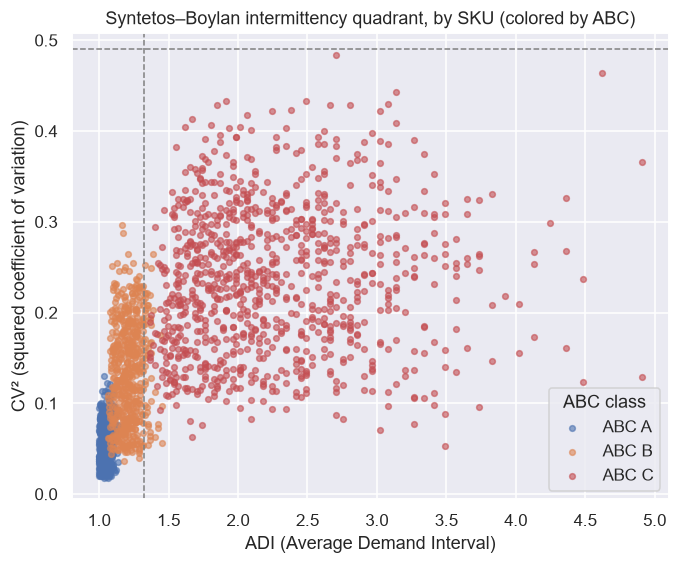

In [19]:
fig, ax = plt.subplots(figsize=(7, 5.5))
palette = {"A": "#4C72B0", "B": "#DD8452", "C": "#C44E52"}
for abc_class, sub in sb.groupby("ABC", observed=True):
    ax.scatter(sub["ADI"], sub["CV2"], s=14, alpha=0.6, label=f"ABC {abc_class}",
               color=palette.get(abc_class))
ax.axvline(1.32, color="grey", linestyle="--", linewidth=1)
ax.axhline(0.49, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("ADI (Average Demand Interval)")
ax.set_ylabel("CV\u00b2 (squared coefficient of variation)")
ax.set_title("Syntetos\u2013Boylan intermittency quadrant, by SKU (colored by ABC)")
ax.legend(title="ABC class")
save_fig(fig, "04_sb_intermittency_quadrant")
plt.show()


**Oservation.** All 1,850 SKUs fall into either **Smooth** (875) or
**Intermittent** (975) quadrants, none are Erratic/Lumpy (CV² never
exceeds ~0.48 in this dataset). Intermittency (ADI ≥ 1.32) is heavily
concentrated in ABC == 'C' (926 of 975 intermittent SKUs), reinforcing
the ABC/SLOB entanglement noted above: slow-moving classification,
intermittency, and the SLOB label are views of largely the same
underlying volume signal in this dataset.


**Time series patterns**

Saved ->artifacts\runs\plots\eda\05_aggregate_time_series.png


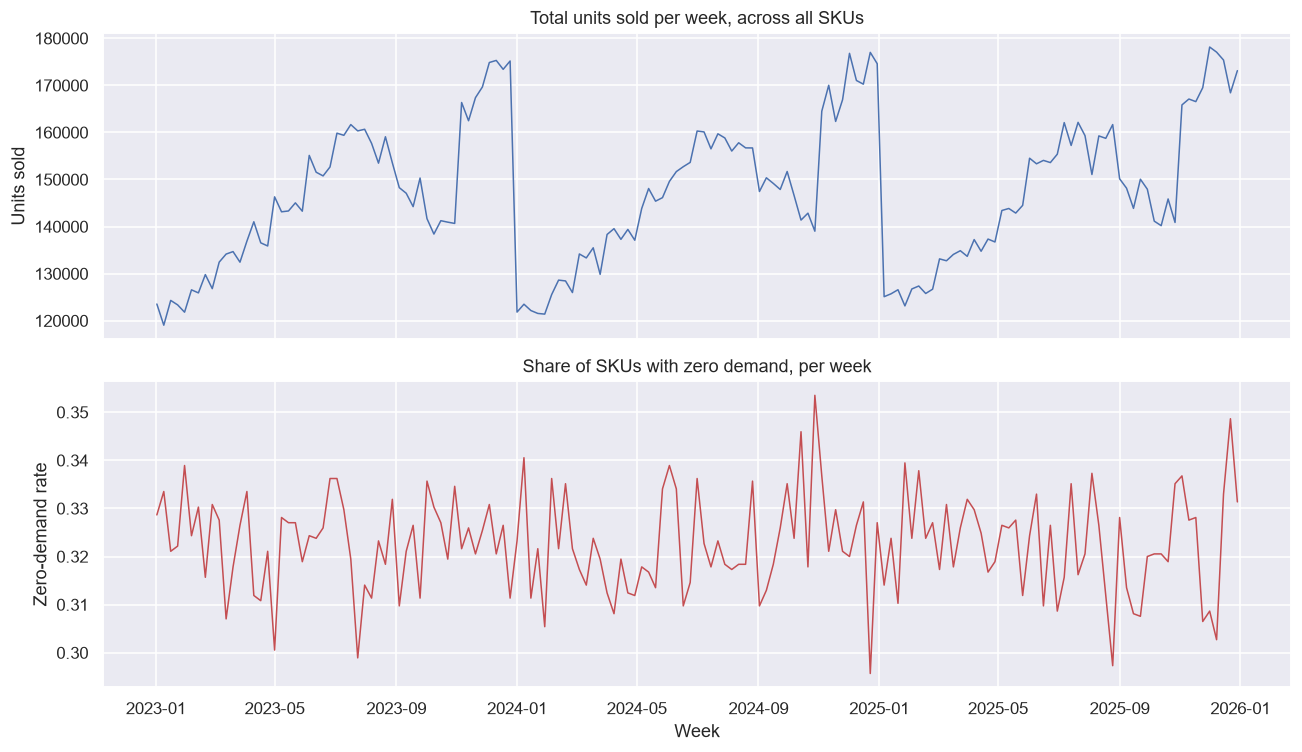

In [20]:
weekly_agg = slob.groupby("Week", observed=True).agg(
    total_units=("Units_Sold", "sum"),
    n_zero_demand=("Units_Sold", lambda s: (s == 0).sum()),
).reset_index()
weekly_agg["zero_demand_rate"] = weekly_agg["n_zero_demand"] / slob["SKU"].nunique()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(weekly_agg["Week"], weekly_agg["total_units"], color="#4C72B0", linewidth=1)
axes[0].set_title("Total units sold per week, across all SKUs")
axes[0].set_ylabel("Units sold")

axes[1].plot(weekly_agg["Week"], weekly_agg["zero_demand_rate"], color="#C44E52", linewidth=1)
axes[1].set_title("Share of SKUs with zero demand, per week")
axes[1].set_ylabel("Zero-demand rate")
axes[1].set_xlabel("Week")

fig.tight_layout()
save_fig(fig, "05_aggregate_time_series")
plt.show()


Saved ->artifacts\runs\plots\eda\06_example_sku_series_by_abc.png


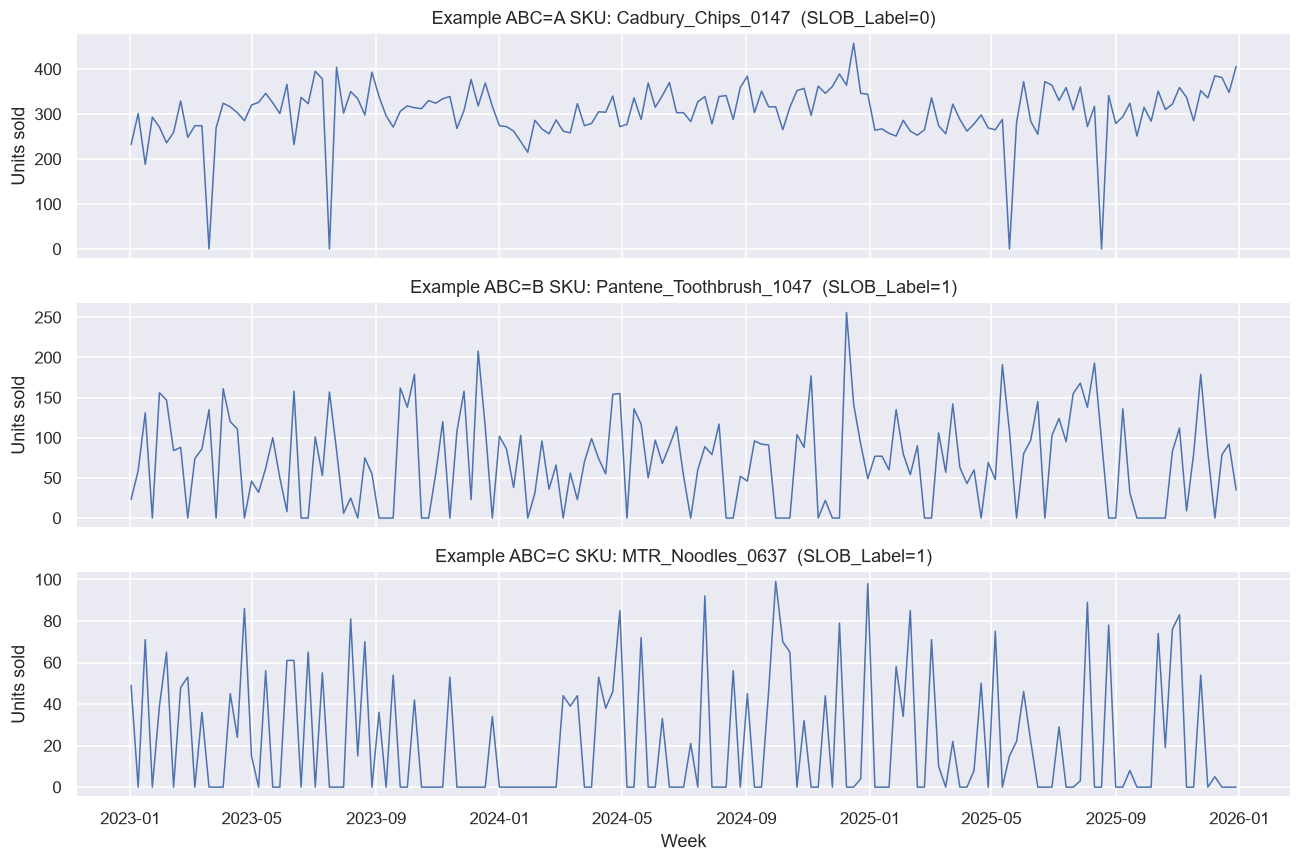

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
rng = np.random.default_rng(42)
for ax, abc_class in zip(axes, ["A", "B", "C"]):
    candidates = slob.loc[slob["ABC"] == abc_class, "SKU"].unique()
    sku = rng.choice(candidates)
    sub = slob[slob["SKU"] == sku]
    ax.plot(sub["Week"], sub["Units_Sold"], color="#4C72B0", linewidth=1)
    ax.set_title(f"Example ABC={abc_class} SKU: {sku}  (SLOB_Label={sub['SLOB_Label'].iloc[0]})")
    ax.set_ylabel("Units sold")
axes[-1].set_xlabel("Week")
fig.tight_layout()
save_fig(fig, "06_example_sku_series_by_abc")
plt.show()


Stock position, pricing, promotion, and macro features vs `SLOB_Label`

Saved ->artifacts\runs\plots\eda\07_stock_price_leadtime_by_label.png


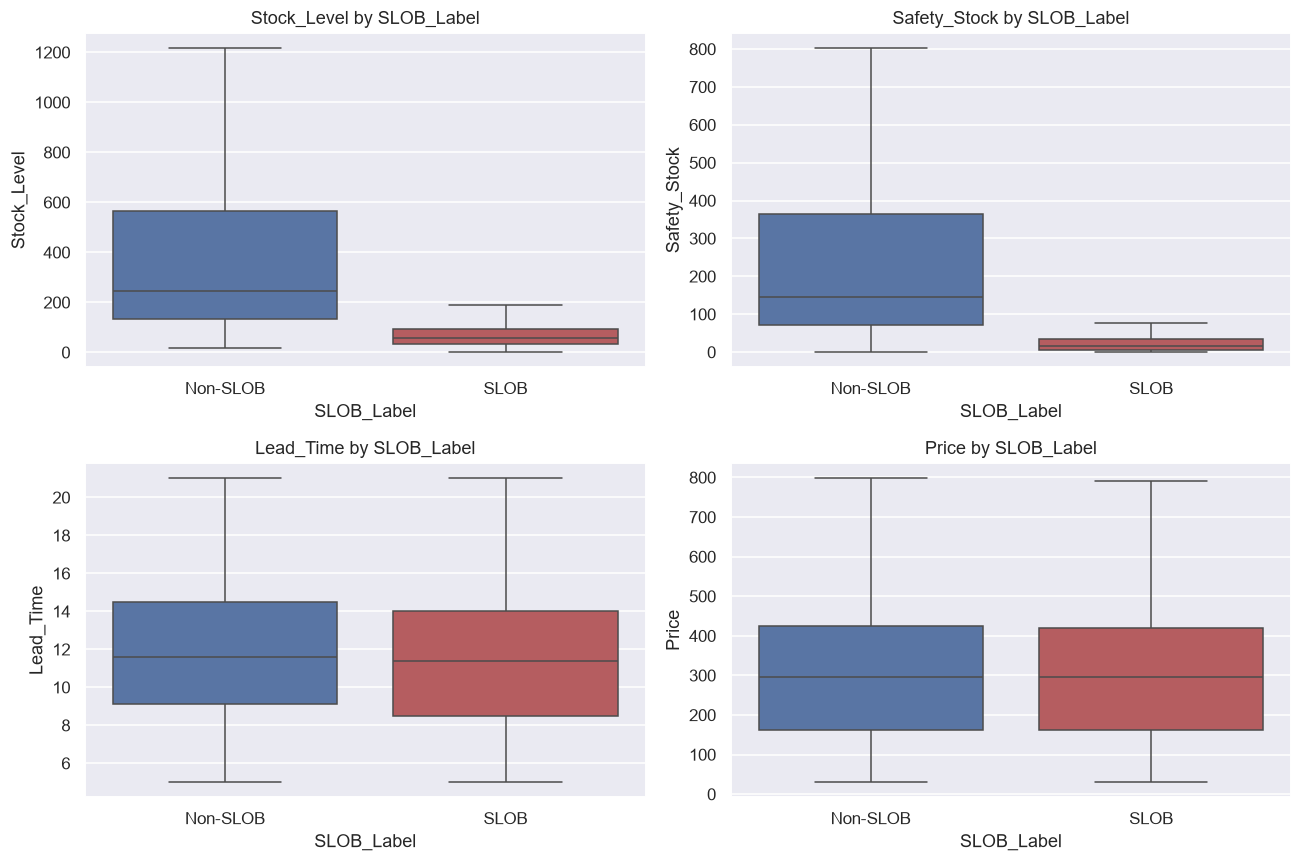

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), ["Stock_Level", "Safety_Stock", "Lead_Time", "Price"]):
    sns.boxplot(data=slob, x="SLOB_Label", y=col, hue="SLOB_Label", ax=ax, showfliers=False, palette=["#4C72B0", "#C44E52"], legend=False)
    ax.set_xticks(range(2))
    ax.set_xticklabels(["Non-SLOB", "SLOB"])
    ax.set_title(f"{col} by SLOB_Label")

fig.tight_layout()
save_fig(fig, "07_stock_price_leadtime_by_label")
plt.show()


In [23]:
promo_rate = slob.groupby("SLOB_Label")["Promotion"].mean()
print("Promotion frequency by label:\n", promo_rate)


Promotion frequency by label:
 SLOB_Label
0    0.202417
1    0.201169
Name: Promotion, dtype: float64


**Observation.** Promotion frequency is essentially identical between SLOB and non-SLOB rows (~50% either way). This may indicate that Promotion has almost no linear relationship with the label.

Saved ->artifacts\runs\plots\eda\08_macro_indices_over_time.png


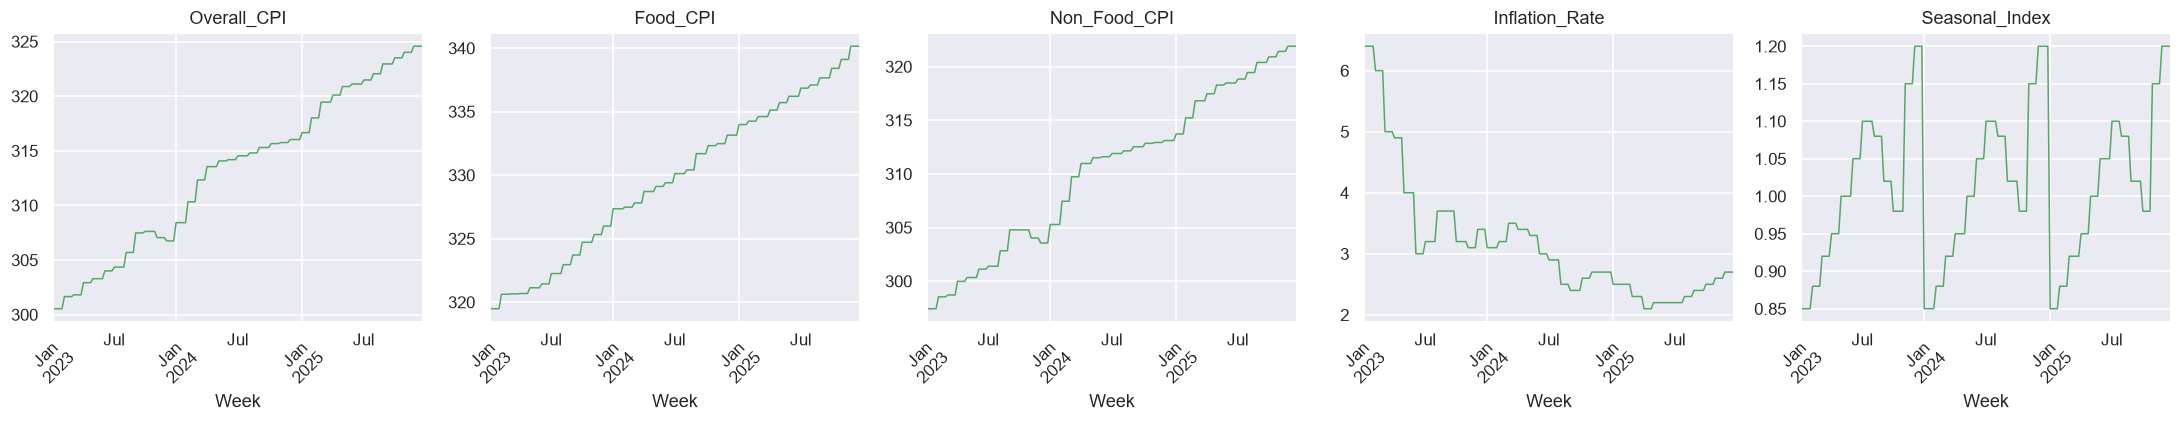

In [24]:
macro_cols = ["Overall_CPI", "Food_CPI", "Non_Food_CPI", "Inflation_Rate", "Seasonal_Index"]
fig, axes = plt.subplots(1, len(macro_cols), figsize=(4 * len(macro_cols), 4))
for ax, col in zip(axes, macro_cols):
    slob.groupby("Week")[col].mean().plot(ax=ax, color="#55A868", linewidth=1)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
save_fig(fig, "08_macro_indices_over_time")
plt.show()

**Observation.** Macro indices (CPI, Inflation_Rate, Seasonal_Index) vary smooth so they may be useful for capturing macro-driven shifts, but not necessarily for separating SLOB from non-SLOB in isolation.


**Product lifecycle**

In [25]:
slob["Product_Age_Weeks"] = (slob["Week"] - slob["Date_First_Listed"]).dt.days / 7
slob['Expiry_Date'] = slob['Date_First_Listed'] + slob['Time_to_Expiry_Days'].apply(pd.Timedelta, unit='D')

Saved ->artifacts\runs\plots\eda\09_lifecycle_distributions.png


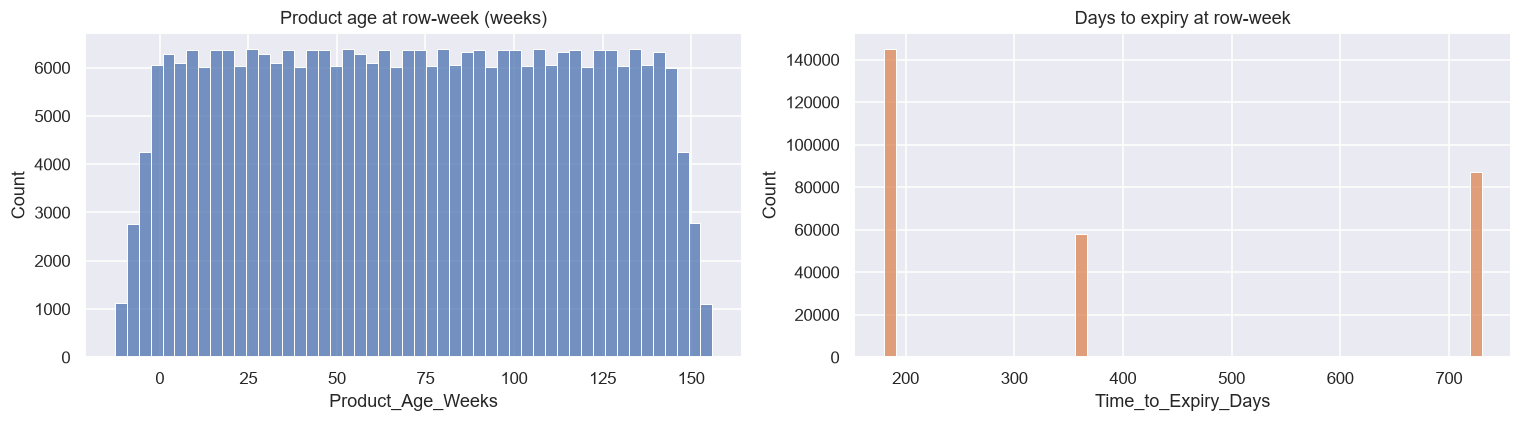

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(slob["Product_Age_Weeks"], bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("Product age at row-week (weeks)")

sns.histplot(slob["Time_to_Expiry_Days"], bins=50, ax=axes[1], color="#DD8452")
axes[1].set_title("Days to expiry at row-week")


fig.tight_layout()
save_fig(fig, "09_lifecycle_distributions")
plt.show()


In [27]:
slob["Time_to_Expiry_Days"].value_counts()

Time_to_Expiry_Days
180    145225
730     87135
365     58090
Name: count, dtype: int64

In [28]:
pd.crosstab(pd.cut(slob["Time_to_Expiry_Days"], bins=[0, 200, 400, 800],
    labels=["180d (short)", "365d (medium)", "730d (long)"]),
    slob["Product_Category"],
)

Product_Category,Ambient Grocery Foods,Household Commodities,Personal Care Products
Time_to_Expiry_Days,,,
180d (short),145225,0,0
365d (medium),0,58090,0
730d (long),0,0,87135


**Observation.** Time to expiry days clusters into exactly three fixed values (180, 365, 730 days) that map to product category (short-shelf-life items are concentrated in perishable-leaning categories). Product age at observation time is roughly uniform over the panel.

**Correlation structure**

Saved ->artifacts\runs\plots\eda\10_correlation_heatmap.png


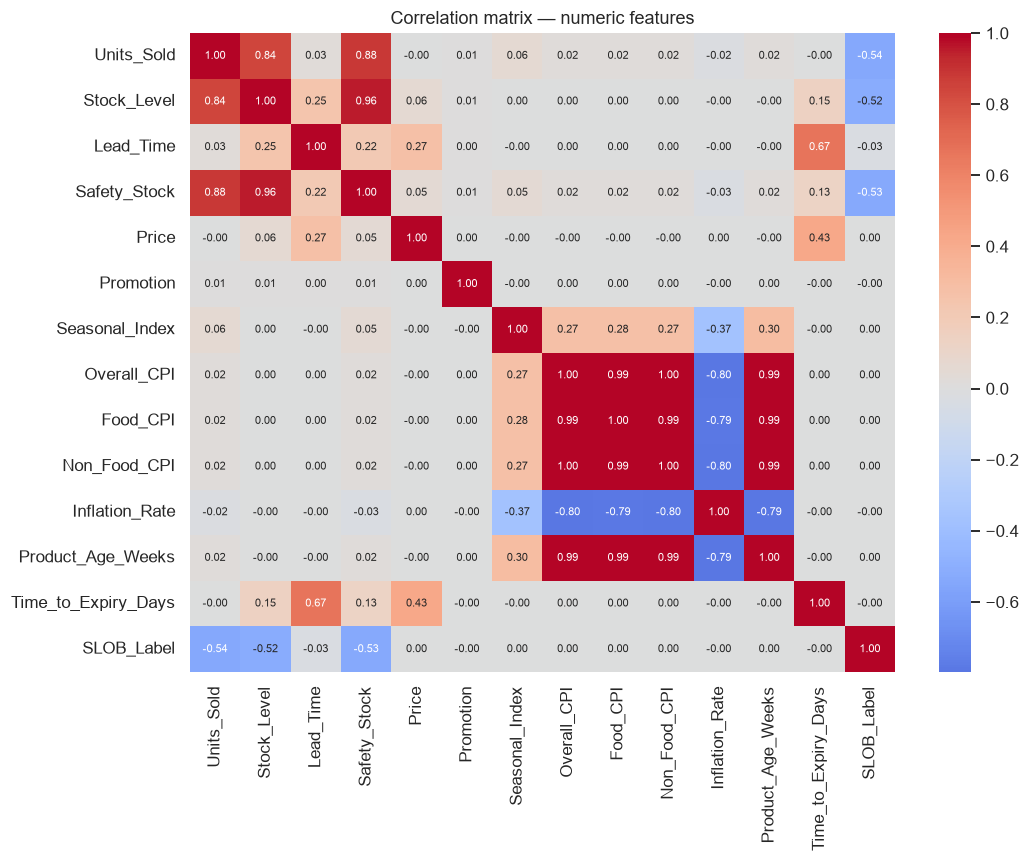

In [29]:
numeric_cols = ["Units_Sold", "Stock_Level", "Lead_Time", "Safety_Stock", "Price",
                 "Promotion", "Seasonal_Index", "Overall_CPI", "Food_CPI", "Non_Food_CPI",
                 "Inflation_Rate", "Product_Age_Weeks", "Time_to_Expiry_Days", "SLOB_Label"]

corr = slob[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation matrix — numeric features")
fig.tight_layout()
save_fig(fig, "10_correlation_heatmap")
plt.show()


In [30]:
print(corr["SLOB_Label"].sort_values(key=np.abs, ascending=False))

SLOB_Label             1.000000
Units_Sold            -0.539900
Safety_Stock          -0.532934
Stock_Level           -0.521283
Lead_Time             -0.026746
Time_to_Expiry_Days   -0.003755
Promotion             -0.001552
Product_Age_Weeks      0.000871
Price                  0.000734
Seasonal_Index         0.000023
Non_Food_CPI           0.000008
Overall_CPI            0.000008
Food_CPI               0.000006
Inflation_Rate        -0.000001
Name: SLOB_Label, dtype: float64


**Feature Engineering**

In [31]:
def add_features(group: pd.DataFrame) -> pd.DataFrame:
    group = group.sort_values("Week").copy()
    units_sold = group["Units_Sold"]

    # Lag
    group["Units_Sold_Lag1"] = units_sold.shift(1)
    group["Units_Sold_Lag4"] = units_sold.shift(4)
    group["Units_Sold_Lag8"] = units_sold.shift(8)

    # Rolling stats
    past_units = units_sold.shift(1)
    group["Rolling_Mean_4W"] = past_units.rolling(4, min_periods=1).mean()
    group["Rolling_Mean_8W"] = past_units.rolling(8, min_periods=1).mean()
    group["Rolling_Std_4W"] = past_units.rolling(4, min_periods=2).std()
    group["Rolling_Std_8W"] = past_units.rolling(8, min_periods=2).std()

    zero_streak = (
        units_sold.eq(0)
        .astype(int)
        .groupby(units_sold.ne(0).cumsum())
        .cumsum()
    )
    group["Consec_Zero_Weeks"] = zero_streak.shift(1) # streak only known before week t


    cumulative_weeks = np.arange(len(group), dtype=float) - 1  # weeks of available *past* history
    cumulative_nonzero = (past_units.gt(0)).cumsum()
    group["ADI_Expanding"] = np.where(cumulative_nonzero > 0, cumulative_weeks / cumulative_nonzero.replace(0, np.nan), np.nan)


    def expanding_cv2(series: pd.Series) -> pd.Series:
        values = series.to_numpy()
        output = np.full(len(values), np.nan)

        for i in range(len(values)):
            history = values[:i]
            non_zero = history[history > 0]
            if len(non_zero) >= 2 and non_zero.mean() > 0:
                output[i] = (non_zero.std(ddof=1) / non_zero.mean()) ** 2
            
        return pd.Series(output, index=series.index)

    group["CV2_Expanding"] = expanding_cv2(units_sold)
    group["Zero_Demand_Ratio_Expanding"] = np.where(
        cumulative_weeks > 0, past_units.eq(0).cumsum() / cumulative_weeks, np.nan
    )

    # price
    group["Price_Change_Pct"] = group["Price"].pct_change()

    return group



In [32]:
slob_feat = slob.groupby("SKU", observed=True, group_keys=True).apply(add_features, include_groups=False)
slob_feat = slob_feat.reset_index(level=0).reset_index(drop=True)
print(f"Feature frame shape: {slob_feat.shape}")
slob_feat[["SKU", "Week", "Units_Sold", "Units_Sold_Lag1", "Rolling_Mean_4W",
         "ADI_Expanding", "CV2_Expanding", "Consec_Zero_Weeks"]].head(10)

Feature frame shape: (290450, 39)


,SKU,Week,Units_Sold,Units_Sold_Lag1,Rolling_Mean_4W,ADI_Expanding,CV2_Expanding,Consec_Zero_Weeks
0,Amul_Biscuits_0166,2023-01-02,287,NaN,NaN,NaN,NaN,NaN
1,Amul_Biscuits_0166,2023-01-09,303,287.0,287.000000,0.000000,NaN,0.0
2,Amul_Biscuits_0166,2023-01-16,260,303.0,295.000000,0.500000,0.001471,0.0
3,Amul_Biscuits_0166,2023-01-23,306,260.0,283.333333,0.666667,0.005884,0.0
4,Amul_Biscuits_0166,2023-01-30,227,306.0,289.000000,0.750000,0.005308,0.0
5,Amul_Biscuits_0166,2023-02-06,375,227.0,274.000000,0.800000,0.014395,0.0
6,Amul_Biscuits_0166,2023-02-13,337,375.0,292.000000,0.833333,0.029060,0.0
7,Amul_Biscuits_0166,2023-02-20,279,337.0,311.250000,0.857143,0.026298,0.0
8,Amul_Biscuits_0166,2023-02-27,327,279.0,304.500000,0.875000,0.023512,0.0
9,Amul_Biscuits_0166,2023-03-06,269,327.0,329.500000,0.888889,0.021244,0.0


In [33]:
first_rows = slob_feat.groupby("SKU", observed=True).head(1)
history_dependent = ["Units_Sold_Lag1", "Rolling_Mean_4W", "ADI_Expanding", "CV2_Expanding"]
print("NaN rate on first row per SKU (expect 1.0 for all):")
print(first_rows[history_dependent].isna().mean())

NaN rate on first row per SKU (expect 1.0 for all):
Units_Sold_Lag1    1.0
Rolling_Mean_4W    1.0
ADI_Expanding      1.0
CV2_Expanding      1.0
dtype: float64


**candidate proxy target for SLOB volume/severity**

Saved ->artifacts\runs\plots\eda\11_slob_volume_proxy_distribution.png


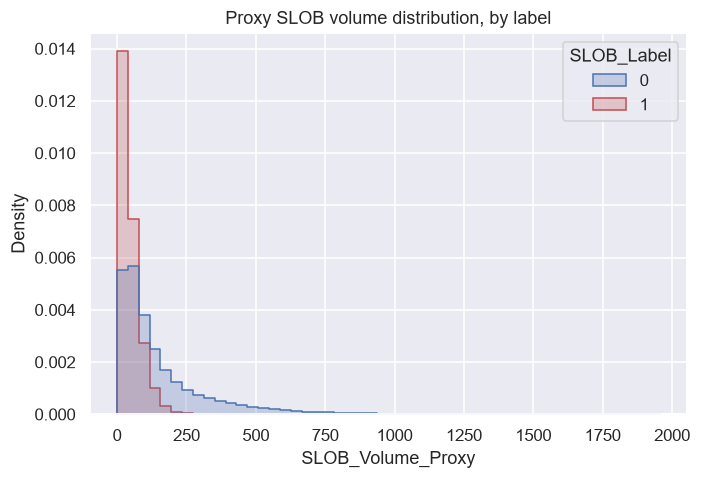

               count        mean         std  min   25%   50%    75%     max
SLOB_Label                                                                  
0           137370.0  153.675016  171.745216  0.0  45.0  93.0  195.0  1955.0
1           153080.0   45.594173   38.624810  0.0  17.0  36.0   62.0   449.0


In [36]:
slob_feat["SLOB_Volume_Proxy"] = (slob_feat["Stock_Level"] - slob_feat["Safety_Stock"]).clip(lower=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=slob_feat, x="SLOB_Volume_Proxy", hue="SLOB_Label", bins=50,
             element="step", stat="density", common_norm=False, ax=ax,
             palette=["#4C72B0", "#C44E52"])
ax.set_title("Proxy SLOB volume distribution, by label")
save_fig(fig, "11_slob_volume_proxy_distribution")
plt.show()

print(slob_feat.groupby("SLOB_Label")["SLOB_Volume_Proxy"].describe())

In [37]:
slob_feat.to_parquet(ARTIFACTS_DATA_FEATURES_DIR, index=False, engine="pyarrow")
print(f"Saved: {ARTIFACTS_DATA_FEATURES_DIR}  ({slob_feat.shape[0]:,} rows x {slob_feat.shape[1]} cols)")

_check = pd.read_parquet(ARTIFACTS_DATA_FEATURES_DIR)
assert _check.shape == slob_feat.shape
print("Round-trip read OK.")
print()
print("Full column list:")
for c in slob_feat.columns:
    print(" -", c)

Saved: c:\Users\Daisy\Desktop\all desktop\Deskstop\Thesis\Daisy\slob-forecasting\artifacts\data\slob_features.parquet  (290,450 rows x 40 cols)
Round-trip read OK.

Full column list:
 - SKU
 - Week
 - Product_Category
 - ABC
 - Date_First_Listed
 - Time_to_Expiry_Days
 - Units_Sold
 - Stock_Level
 - Lead_Time
 - Safety_Stock
 - Reorder_Level
 - Price
 - Promotion
 - Seasonal_Index
 - Overall_CPI
 - Food_CPI
 - Non_Food_CPI
 - Inflation_Rate
 - Rolling_4W_Avg
 - Rolling_8W_Avg
 - ADI
 - CV2
 - Zero_Demand_Ratio
 - Consec_Zero_Weeks
 - Inventory_Turnover
 - SLOB_Label
 - Product_Age_Weeks
 - Expiry_Date
 - Units_Sold_Lag1
 - Units_Sold_Lag4
 - Units_Sold_Lag8
 - Rolling_Mean_4W
 - Rolling_Mean_8W
 - Rolling_Std_4W
 - Rolling_Std_8W
 - ADI_Expanding
 - CV2_Expanding
 - Zero_Demand_Ratio_Expanding
 - Price_Change_Pct
 - SLOB_Volume_Proxy


#### Summary

**Demand characteristics:**
- Overall zero-demand rate is 32.3%, rising sharply from 3.8% (ABC=A) to
  17.0% (ABC=B) to 52.7% (ABC=C) confirms strong, ABC-aligned demand
  intermittency, consistent with the literature review's framing of FMCG
  intermittency.

- All SKUs classify as **Smooth** or **Intermittent** under Syntetos–Boylan
  (none Erratic/Lumpy); intermittency concentrates almost entirely in
  ABC=C.

**Critical modelling issues surfaced:**
1. **'ABC' near-perfectly determines 'SLOB_Label'** (A→0 always, C→1
   always, only B carries real signal, ~8.9% SLOB rate within B). Including
   'ABC' as a feature would produce a trivially high but meaningless
   benchmark score.

2. **'SLOB_Label' is static for 99.8% of SKUs** across the full 157-week
   panel, it doesn't behave like a "multi-step ahead forecast" target as defined.
